<a href="https://colab.research.google.com/github/vedantjoshi24-alt/Deep_Learning/blob/main/Assignment_03/DL_Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   Learning Rate  Accuracy
0        0.10000    0.6189
1        0.01000    0.9679
2        0.00100    0.9745
3        0.00001    0.8603


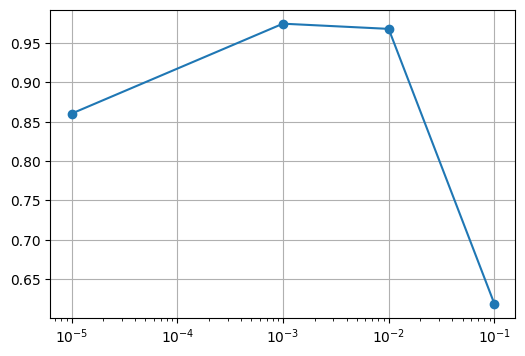

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   Epochs  Accuracy
0       5    0.9724
1      10    0.9752
2      20    0.9752


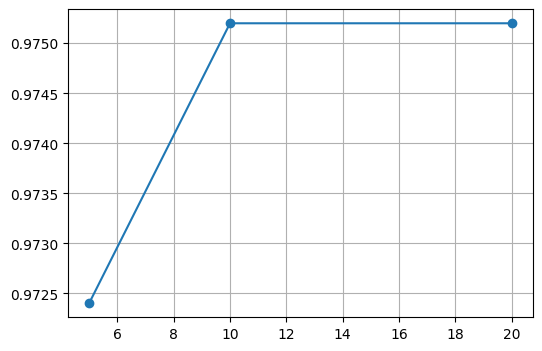

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8941 - loss: 0.3735 - val_accuracy: 0.9476 - val_loss: 0.1883
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9553 - loss: 0.1539 - val_accuracy: 0.9582 - val_loss: 0.1398
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9693 - loss: 0.1073 - val_accuracy: 0.9640 - val_loss: 0.1205
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9762 - loss: 0.0801 - val_accuracy: 0.9657 - val_loss: 0.1112
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9816 - loss: 0.0613 - val_accuracy: 0.9719 - val_loss: 0.0959
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9849 - loss: 0.0503 - val_accuracy: 0.9697 - val_loss: 0.1057
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9872 - loss: 0.0420 - val_accuracy: 0.9714 - val_loss: 0.0986
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9896 - loss: 0.0335 - val_accuracy: 0.

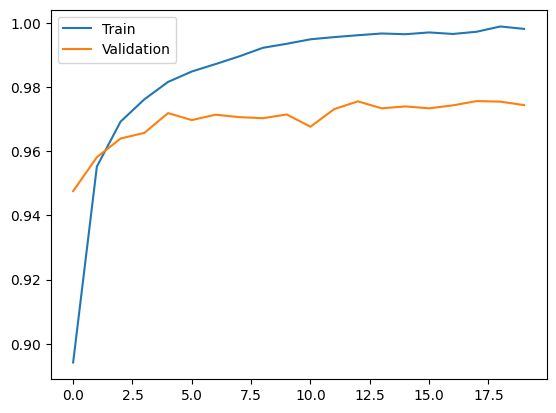

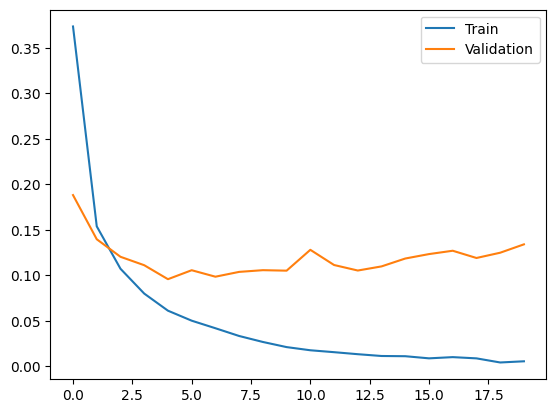

0.10716517269611359 0.9750000238418579


In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import pandas as pd

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train.reshape(60000, 784).astype("float32") / 255.0
x_test = x_test.reshape(10000, 784).astype("float32") / 255.0

def build_model(lr):
    model = Sequential([
        Dense(128, activation="relu", input_shape=(784,)),
        Dense(64, activation="relu"),
        Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

learning_rates = [0.1, 0.01, 0.001, 0.00001]

lr_data = []

for lr in learning_rates:
    net = build_model(lr)
    net.fit(x_train, y_train, epochs=5, batch_size=128, verbose=0)
    loss, acc = net.evaluate(x_test, y_test, verbose=0)
    lr_data.append([lr, acc])

lr_df = pd.DataFrame(lr_data, columns=["Learning Rate", "Accuracy"])
print(lr_df)

plt.figure(figsize=(6,4))
plt.plot(lr_df["Learning Rate"], lr_df["Accuracy"], marker="o")
plt.xscale("log")
plt.grid(True)
plt.show()

epoch_values = [5, 10, 20]

epoch_data = []

for ep in epoch_values:
    net = build_model(0.001)
    net.fit(
        x_train,
        y_train,
        validation_split=0.2,
        epochs=ep,
        batch_size=128,
        verbose=0
    )
    loss, acc = net.evaluate(x_test, y_test, verbose=0)
    epoch_data.append([ep, acc])

epoch_df = pd.DataFrame(epoch_data, columns=["Epochs", "Accuracy"])
print(epoch_df)

plt.figure(figsize=(6,4))
plt.plot(epoch_df["Epochs"], epoch_df["Accuracy"], marker="o")
plt.grid(True)
plt.show()

model = build_model(0.001)

history = model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=128
)

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.legend(["Train", "Validation"])
plt.show()

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.legend(["Train", "Validation"])
plt.show()

loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(loss, accuracy)
